# Chapter 12: Intrusion Detection and Prevention Systems

> "An alarm that goes off every time the wind blows is not a security system." security aphorism

---

## Learning Objectives

After completing this chapter, you will be able to:

1. Distinguish intrusion detection from intrusion prevention and network-based from host-based.
2. Explain signature-based, anomaly-based, and stateful-protocol analysis detection methods.
3. Describe false positives, false negatives, and the precision/recall trade-off.
4. Explain how Snort rules are structured and write a basic rule.
5. Describe Security Information and Event Management (SIEM) and its role.
6. Explain User and Entity Behaviour Analytics (UEBA) and how it detects insider threats.
7. Describe threat hunting and how it differs from reactive alerting.
8. Interpret a detection alert and begin a triage workflow.

## Key Terms

- **IDS**: Intrusion Detection System; monitors and alerts on suspicious activity.
- **IPS**: Intrusion Prevention System; actively blocks suspicious traffic in line.
- **NIDS**: Network-based IDS; monitors network traffic.
- **HIDS**: Host-based IDS; monitors a single host's activity.
- **Signature**: a pattern matched against known attack traffic or behaviour.
- **Anomaly detection**: flagging deviations from a baseline of normal behaviour.
- **False positive (FP)**: an alert fired on benign activity.
- **False negative (FN)**: a real attack that does not trigger an alert.
- **Precision**: TP / (TP + FP); fraction of alerts that are real attacks.
- **Recall**: TP / (TP + FN); fraction of real attacks that trigger an alert.
- **SIEM**: Security Information and Event Management; aggregates and correlates log data.
- **SOAR**: Security Orchestration, Automation, and Response.
- **UEBA**: User and Entity Behaviour Analytics.
- **Threat hunting**: proactive search for adversary activity not caught by automated alerting.

---

## Detection System Types

### Network-Based IDS and IPS

NIDS sensors are placed at strategic network points: the internet perimeter, between zones, and
at internal aggregation points. They receive a copy of network traffic (via a SPAN port or network
tap) and inspect it against rules. An IPS is placed inline and can drop or reset traffic that
matches rules, at the cost of adding latency and creating a potential failure point. Many
organisations deploy IDS out-of-band and use the firewall or NGFW for actual blocking.

#### Placement Considerations

NIDS inside the firewall sees decrypted traffic on the internal network but misses encrypted
external traffic. NIDS outside the firewall sees all inbound traffic but cannot inspect encrypted
payloads. TLS inspection at the firewall or proxy allows the IDS to see decrypted traffic without
sitting outside the firewall, at the cost of certificate management complexity.

### Host-Based IDS

HIDS monitors local system activity: file system changes (integrity monitoring), process creation,
registry modifications, login events, and system calls. Examples include OSSEC, Wazuh, and
commercial endpoint detection and response (EDR) tools. HIDS is not affected by network-level
encryption because it observes behaviour on the host after decryption.

---

## Detection Methods

### Signature-Based Detection

Signature detection matches traffic or behaviour against a database of known attack patterns.
Snort, Suricata, and Zeek support signature-based detection. Advantages: low false-positive rate
for known attacks, deterministic, and auditable. Limitations: zero-day attacks have no signature;
attackers can modify payloads to evade known signatures; high maintenance burden as signatures must
be continuously updated.

#### Snort Rule Anatomy

A Snort rule has two parts: the rule header and the rule body.

```
alert tcp any any -> 192.168.1.0/24 80 (msg:"GET /etc/passwd"; content:"/etc/passwd"; sid:1000001; rev:1;)
```

- `alert`: action (alert, log, drop, reject).
- `tcp`: protocol.
- `any any`: source IP and port.
- `->`: direction.
- `192.168.1.0/24 80`: destination network and port.
- `msg`: human-readable alert message.
- `content`: byte pattern to match in payload.
- `sid`: unique rule identifier.
- `rev`: revision number.

### Anomaly-Based Detection

Anomaly detection establishes a baseline of normal behaviour and alerts on deviations. A user
who logs in from a new country, accesses 10x their normal volume of files, or connects at
3 AM when they never have before triggers an anomaly alert. Machine learning models (isolation
forest, autoencoders) are used for complex baseline modelling.

#### The Precision/Recall Trade-Off

Anomaly detection suffers from high false-positive rates because legitimate behaviour is variable.
Tightening the anomaly threshold reduces false positives but increases false negatives. A low-
sensitivity model misses real attacks (high FN rate); a high-sensitivity model alerts on benign
activity constantly (high FP rate). Effective tuning requires labelled historical data and business
context about what is truly abnormal.

### Stateful Protocol Analysis

Stateful protocol analysis enforces expected protocol behaviour at the state-machine level. An HTTP
parser flags requests that deviate from RFC 7230, such as oversized headers or unusual method
verbs, even if no signature matches. This catches protocol exploitation and evasion techniques
that modify known payloads to avoid content matching.

---

## SIEM and Log Aggregation

### SIEM Architecture

A SIEM collects logs from every source in the environment: firewalls, endpoints, servers,
applications, cloud APIs, network devices, and authentication systems. It normalises them into
a common schema, stores them long-term, and correlates events across sources to detect complex
attack chains that no single source could identify.

#### Detection Use Cases

A SIEM correlation rule firing on: failed login to account A, successful login to account A 5
minutes later from a different IP, followed by file access to a sensitive share, followed by
data transfer to an external IP captures the Mitre ATT&CK pattern for credential stuffing,
initial access, and exfiltration. No individual event is alarming; the sequence is.

### SIEM Challenges

A SIEM that receives 100,000 events per second and generates 10,000 alerts per day has an
alert-fatigue problem. Analysts who cannot process the alert volume begin to ignore alerts.
Effective SIEM operation requires: tuned correlation rules that reduce noise, prioritisation by
asset criticality, automated enrichment (IP reputation, known-bad hashes), and analyst workflows
that handle the highest-priority alerts first.

---

## UEBA and Threat Hunting

### User and Entity Behaviour Analytics

UEBA applies statistical models to user, host, and network entity behaviour over time. It detects:
accounts exhibiting credential-stuffing patterns, service accounts behaving like user accounts,
hosts communicating with unusual peers, and data access volumes that deviate from historical
baselines. UEBA is particularly effective against insider threats and compromised accounts whose
credentials are valid but whose behaviour is abnormal.

### Threat Hunting

Threat hunting is the proactive, hypothesis-driven search for adversary activity that has not
triggered automated alerts. A hunt starts with a hypothesis (e.g., "assume an attacker has
compromised a service account and is using it for lateral movement") and searches for evidence
that confirms or disproves it. Hunters use raw log data, threat intelligence, and knowledge of
adversary TTPs rather than relying on pre-written correlation rules.

#### Hunt Methodology

1. Develop a hypothesis based on threat intelligence, recent incident data, or MITRE ATT&CK.
2. Define the data sources that would contain evidence if the hypothesis is true.
3. Query those data sources for the expected indicators.
4. Analyse results, adjusting the query iteratively.
5. Document the hunt, its findings, and any detection gaps identified.

---
- **Cyber Kill Chain / MITRE ATT&CK**: models of attacker stages and of tactics/techniques used to organize detection.
- **SIEM / SOAR / EDR / NDR / XDR**: the detection-and-response platform stack.
- **Detection engineering / threat hunting**: writing and tuning detections; proactively hunting evaded adversaries.
- **MTTD / MTTR**: mean time to detect / respond, the key SOC metrics.


<!--DEF12-->
## Intrusion Detection Systems: What They Watch

Having framed detection conceptually, we can be precise about what an **intrusion detection system (IDS)** is
and does. An IDS detects actions and events that attempt to compromise the confidentiality, integrity, or
availability of assets and resources. It is fundamentally a **passive** device: it monitors and **alerts**, but
does not block. Detection can run in real time or out-of-band, and an IDS is only as good as its input, so
operators must know what to look for; most systems are signature-based, while anomaly-based systems can catch
oddities in transactions that no signature anticipated.

IDS deployments fall into three categories. A **network-based IDS (NIDS)** inspects traffic on the wire and may
be hardware or software, sometimes built into bastion hosts as application-level or multilayer firewalls;
monitoring requires the sensor to see traffic via an **inline** placement, a **SPAN/mirror port**, or a network
**tap**, and the most common open-source NIDS is **Snort**. A **host-based IDS (HIDS)** lives as an application
on an endpoint and examines the whole system, watching security events, normal communications, system behavior,
and software integrity; common HIDS tools include **OSSEC**, **Tripwire**, and **AIDE**. Finally,
**physically-based** detection (security guards, store gates, cameras, alarms) also monitors and alerts and can
double as a deterrent, a reminder that detection is not only digital.


## Intrusion Prevention Systems: From Alert to Action

An IDS tells you something is wrong; the natural next step is to **stop** it, which is the job of an
**intrusion prevention system (IPS)**. An IPS performs the same detection of CIA-threatening actions and then
**takes action based on the signatures**, acting as an **active** gatekeeper that monitors, alerts, and blocks.
To block, it must operate **in real time and inline** in the traffic path, which makes IPS trickier to deploy
than IDS: because traffic flows through it, **if the system fails, traffic stops flowing** (a fail-closed
trade-off that must be planned for).

Like detection, prevention comes in network, host, and physical forms. A **network-based IPS (NIPS)** is
usually hardware (large networks favor dedicated appliances) placed inline for maximum effect; some software
can send out-of-band TCP resets to tear down connections, but that is uncommon. A **host-based IPS (HIPS)**
lives as an application and can monitor nearly every aspect of a system, and it is often **sandboxed or
virtualized** so that analyzing hostile code does not infect the host. Physically-based prevention is anything
that physically stops harm (an electric fence is the textbook, if impractical, example). The defining
difference from an IDS is the verb: detection *observes*, prevention *intervenes*.

```{mermaid}
flowchart LR
    T[Traffic] --> S{Sensor}
    S -->|IDS: passive, copy via SPAN/tap| A[Alert only]
    T --> I{IPS: inline}
    I -->|matches signature/behavior| B[Block / drop / reset]
    I -->|clean| F[Forward]
    A -.-> SIEM[SIEM / analyst]
    B -.-> SIEM
```


## Detection Methods: Signature, Heuristic, and Anomaly

Whether a tool detects or prevents, and whether it guards the network, the host, or a file, it relies on one or
more **detection methods**, and understanding their trade-offs explains why defense-in-depth layers several of
them. The same three methods underpin IDS, IPS, antivirus, traffic analysis, and application security alike.

**Signature-based detection** matches content against known patterns: byte sequences, file types, ports,
protocols, and hashes. Its advantages are that signatures are updated frequently (sometimes several times a
day), can be written for IDS/IPS/applications, can point to a whole *family* of malicious content, and produce
few false positives. Its weaknesses are that signatures can be evaded, **zero-day threats have no signature**
(false negatives), update deployment can lag, and the more you check for, the more data you must match.

**Heuristic (behavior-based) detection** looks at what content *does*: file changes, network traffic, and the
same characteristics a signature might use. It is usually faster (it need not consult every signature), focuses
on behavior, can be harder to evade because malware tends to follow behavioral patterns, and may avoid scanning
a file at all. Its downsides are that it yields generic rather than detailed verdicts, can still be evaded, and
tends to raise **both** false positives and false negatives.

**Other methods** push further into **anomaly detection**: building a baseline from historical traffic
patterns and statistical models of how information is normally accessed, then flagging deviations, increasingly
with **machine learning** (the techniques developed in Chapter 17, including the author's encrypted
log-anomaly work). No single method suffices, which is exactly why mature defenses combine signatures for
known threats, heuristics for variants, and anomaly/ML for the genuinely novel.

| | Signature-based | Heuristic / behavior | Anomaly / ML |
|---|---|---|---|
| Detects | known patterns | suspicious behavior | deviation from baseline |
| Zero-days | misses (FN) | may catch | may catch |
| False positives | few | more | tunable, often more |
| Output | specific (family) | generic | statistical |

```{admonition} Knowledge Check
:class: tip
1. State the one-word difference in what an IDS does versus an IPS, and the deployment consequence of that
   difference.
2. Why does signature-based detection struggle with zero-day threats, and which method compensates?
3. Why must an IPS typically be deployed inline while an IDS can sit on a SPAN port?

*Answers:* (1) An IDS *alerts* (passive) while an IPS *blocks* (active); because the IPS sits inline, its
failure can stop traffic (fail-closed), so it needs careful availability planning. (2) A zero-day has no
existing signature, producing false negatives; heuristic/behavioral and anomaly/ML detection can flag it by
behavior or deviation. (3) To block traffic an IPS must be in the actual path; an IDS only needs a copy of the
traffic, which a SPAN port or tap provides.
```


<!--CH12KC-->
## The Cyber Kill Chain and MITRE ATT&CK

Detection is most effective when organized around how attackers actually operate, and two models dominate. The
**Cyber Kill Chain** (Lockheed Martin) describes an intrusion as seven sequential stages, reconnaissance,
weaponization, delivery, exploitation, installation, command and control (C2), and actions on objectives, and
its defensive value is that **the earlier in the chain a defender detects and breaks it, the cheaper the
incident**. A scan caught at reconnaissance (Chapter 8) is far less costly than ransomware caught at actions on
objectives. The kill chain is linear and attacker-centric, which is also its limitation against modern,
non-linear intrusions.

**MITRE ATT&CK** complements it with a detailed, empirically derived knowledge base of adversary **tactics**
(the *why*, such as Persistence or Lateral Movement), **techniques** (the *how*, such as pass-the-hash), and
real-world procedures. Where the kill chain gives a high-level narrative, ATT&CK gives a granular matrix that
maps directly to detections: a SOC measures its **coverage** by which ATT&CK techniques it can detect, and
**detection engineering** (below) writes rules technique by technique. Together they turn raw telemetry into
purposeful detection, ensuring sensors watch for what attackers really do rather than only for known-bad
signatures.

```{mermaid}
flowchart LR
    R[Recon] --> W[Weaponize] --> D[Deliver] --> E[Exploit] --> I[Install] --> C[C2] --> A[Actions on objectives]
    R -.detect early = cheap.-> X[Break the chain]
    A -.detect late = costly.-> X
```


## SIEM, SOAR, XDR, and EDR: The Detection Stack

Modern detection is delivered through a stack of overlapping platforms whose acronyms confuse newcomers, so it
helps to place each precisely. A **SIEM (Security Information and Event Management)** aggregates logs and events
from across the enterprise, normalizes them, and **correlates** them to raise alerts and support investigation
and compliance (Chapters 3 and 19); it is the analyst's single pane of glass but generates many alerts.
**SOAR (Security Orchestration, Automation, and Response)** sits on top to **automate** repetitive response
with **playbooks**, enriching alerts, opening tickets, and quarantining hosts without human delay, addressing
the alert-fatigue problem SIEM creates. **EDR (Endpoint Detection and Response)** instruments endpoints
directly to detect and respond to malicious behavior on the host (Chapter 15), recording process trees and
enabling remote isolation. **NDR (Network Detection and Response)** does the analogous job for network traffic
(Chapter 11). **XDR (Extended Detection and Response)** unifies endpoint, network, identity, email, and cloud
telemetry into one correlated detection-and-response layer, the convergence of the others.

| Platform | Scope | Primary job |
|---|---|---|
| SIEM | All log sources | Aggregate, correlate, alert, retain |
| SOAR | Response workflow | Automate and orchestrate response (playbooks) |
| EDR | Endpoints | Detect and respond on the host |
| NDR | Network | Detect and respond on traffic |
| XDR | Cross-layer | Unified correlation and response across all of the above |

These feed the **security operations center (SOC)**, where tiered analysts triage alerts; the architecture's
goal is to shorten **mean time to detect (MTTD)** and **mean time to respond (MTTR)**, the metrics by which a
detection program is judged.


## Detection Engineering, Threat Hunting, and Deception

Tools are only as good as the detections loaded into them, which is the discipline of **detection
engineering**: writing, testing, and tuning rules, increasingly as version-controlled **detection-as-code**.
Rules are expressed in formats such as **Snort/Suricata** signatures for network traffic, **YARA** for file
content, and **Sigma**, a vendor-neutral language that compiles to many SIEMs. A simple Sigma-style rule reads:

```yaml
# Sigma-style detection: many failed logins then a success (possible brute force)
title: Possible Successful Brute Force
logsource: { product: windows, service: security }
detection:
  failures:  { EventID: 4625 }      # failed logon
  success:   { EventID: 4624 }      # successful logon
  timeframe: 5m
  condition: failures | count() > 20 followed by success
level: high
```

Every rule lives on the precision-versus-recall curve of Chapter 12's detection methods: too loose and analysts
drown in false positives, too tight and real attacks slip through, so tuning is continuous. Beyond automated
rules, **threat hunting** is the proactive, hypothesis-driven search for adversaries who evaded detection: a
hunter starts from an ATT&CK technique or a hypothesis ("an attacker would use WMI for lateral movement"),
queries the telemetry, and either finds evil or turns the finding into a new detection. Hunting prioritizes
durable **TTPs** over brittle **indicators of compromise (IOCs)**, climbing the "pyramid of pain." Finally,
the **deception** of Chapter 11 (honeypots, honeytokens) feeds high-confidence alerts straight into this stack.

```{admonition} Knowledge Check
:class: tip
1. Why does detecting an intrusion earlier in the Cyber Kill Chain reduce its cost?
2. Distinguish the jobs of SIEM, SOAR, EDR, and XDR.
3. What does a threat hunter prioritize over indicators of compromise, and why?

*Answers:* (1) Earlier stages (recon, delivery) precede damage, so breaking the chain there prevents the costly
later stages (installation, C2, actions on objectives). (2) SIEM aggregates and correlates logs to alert; SOAR
automates and orchestrates response via playbooks; EDR detects/responds on endpoints; XDR unifies endpoint,
network, identity, and cloud telemetry into one correlated layer. (3) Durable TTPs (tactics, techniques,
procedures) over IOCs, because attackers change indicators (hashes, IPs) easily but changing their behavior is
costly, so TTP-based detection is harder to evade.
```


## Why This Matters

An IDS is only as good as its alerting, and alerting is only as good as the analyst who responds.
The most sophisticated SIEM is worthless if alerts go unread. Effective detection requires tuned
rules, prioritised alerts, trained analysts, and well-practised response workflows. The measure
of a detection capability is not the number of rules deployed but the mean time to detect a real
intrusion. World-class programmes achieve MTTD measured in hours or days; many organisations
discover breaches weeks or months after initial compromise.

---

## News in Focus

Post-incident analysis of major breaches has repeatedly shown that the intrusion was detectable
much earlier than it was discovered. Indicators including unusual authentication patterns, anomalous
data transfers, and new scheduled tasks were present in logs that the organisation collected but
did not analyse in real time. These findings drive investment in SIEM tuning and SOC staffing:
collecting logs is the floor, not the ceiling, of a detection capability.

---


Configuration                   Precision     Recall       F1
--------------------------------------------------------------
Signature-only (tight)             88.89%     40.00%   55.17%
Anomaly (loose)                    65.22%     75.00%   69.77%
Tuned SIEM                         85.00%     68.00%   75.56%
ML UEBA                            80.00%     80.00%   80.00%


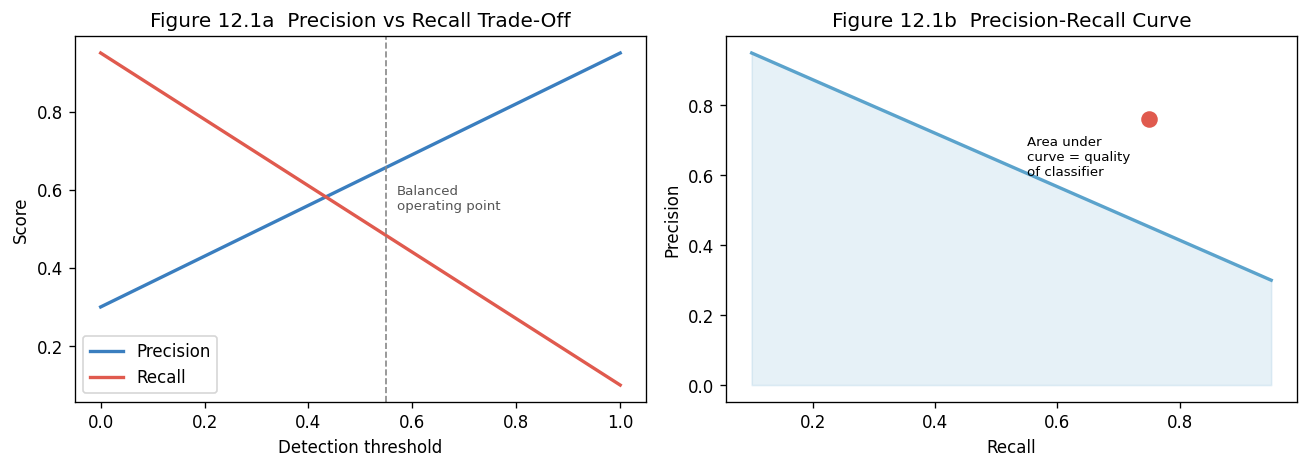


=== Snort Rule Simulator ===
  'GET /index.html HTTP/1.1'                                -> NO MATCH
  'GET /../../etc/passwd HTTP/1.1'                          -> ALERT: Possible /etc/passwd access via HTTP
  "POST /login username=admin'%20OR%201=1%20-- HTTP/1.1"    -> NO MATCH
  'GET /search?q=<script>alert(1)</script> HTTP/1.1'        -> ALERT: XSS script tag
  'GET /page HTTP/1.1\r\nUser-Agent: Nmap Scripting Engine' -> ALERT: Nmap default scan UA


In [1]:
# Chapter 12 -- Detection metrics: precision, recall, ROC and Snort rule simulator
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
from IPython.display import display, Image

# ── Precision / Recall metrics ────────────────────────────────────────────────
def metrics(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr       = fp / (fp + (100 - tp - fn)) if (fp + (100 - tp - fn)) > 0 else 0
    return precision, recall, f1, fpr

configs = [
    ("Signature-only (tight)", 40, 5,  60),
    ("Anomaly (loose)",        75, 40, 25),
    ("Tuned SIEM",             68, 12, 32),
    ("ML UEBA",                80, 20, 20),
]

print(f"{'Configuration':<30} {'Precision':>10} {'Recall':>10} {'F1':>8}")
print("-" * 62)
for name, tp, fp, fn in configs:
    p, r, f1, fpr = metrics(tp, fp, fn)
    print(f"{name:<30} {p:>10.2%} {r:>10.2%} {f1:>8.2%}")

# ── Precision-Recall trade-off visualisation ──────────────────────────────────
thresholds = np.linspace(0, 1, 50)
precision_curve = 0.3 + 0.65 * thresholds
recall_curve    = 0.95 - 0.85 * thresholds

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(thresholds, precision_curve, label="Precision", color="#3a7ebf", lw=2)
axes[0].plot(thresholds, recall_curve,   label="Recall",    color="#e05a4e", lw=2)
axes[0].axvline(0.55, color="#888", ls="--", lw=1)
axes[0].text(0.57, 0.55, "Balanced\noperating point", fontsize=8, color="#555")
axes[0].set_xlabel("Detection threshold"); axes[0].set_ylabel("Score")
axes[0].set_title("Figure 12.1a  Precision vs Recall Trade-Off"); axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color="#5ba3cc", lw=2)
axes[1].fill_between(recall_curve, precision_curve, alpha=0.15, color="#5ba3cc")
axes[1].scatter([0.75], [0.76], color="#e05a4e", zorder=5, s=80)
axes[1].text(0.55, 0.6, "Area under\ncurve = quality\nof classifier", fontsize=8)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Figure 12.1b  Precision-Recall Curve")

plt.tight_layout()
_buf = BytesIO()
plt.savefig(_buf, format="png", dpi=120, bbox_inches="tight")
plt.close(); _buf.seek(0)
display(Image(data=_buf.read()))

# ── Simple Snort rule simulator ───────────────────────────────────────────────
print("\n=== Snort Rule Simulator ===")

def snort_match(rule_content, payload):
    return rule_content.lower() in payload.lower()

rules = [
    dict(sid=1001, msg="Possible /etc/passwd access via HTTP", content="/etc/passwd"),
    dict(sid=1002, msg="SQL injection OR 1=1 pattern",        content="OR 1=1"),
    dict(sid=1003, msg="XSS script tag",                     content="<script>"),
    dict(sid=1004, msg="Nmap default scan UA",               content="Nmap Scripting Engine"),
]

payloads = [
    "GET /index.html HTTP/1.1",
    "GET /../../etc/passwd HTTP/1.1",
    "POST /login username=admin'%20OR%201=1%20-- HTTP/1.1",
    "GET /search?q=<script>alert(1)</script> HTTP/1.1",
    "GET /page HTTP/1.1\r\nUser-Agent: Nmap Scripting Engine",
]

for payload in payloads:
    matched = [r for r in rules if snort_match(r["content"], payload)]
    status = f"ALERT: {', '.join(r['msg'] for r in matched)}" if matched else "NO MATCH"
    print(f"  {payload[:55]!r:<57} -> {status}")


## Review Questions (MCQ)

**Q1.** The difference between IDS and IPS is primarily that IPS:
A. Uses only signature detection  B. Is placed inline and can actively block traffic  C. Only monitors host activity  D. Requires a SIEM

**Q2.** A false negative in intrusion detection means:
A. An alert fired on benign traffic  B. A real attack that did not trigger an alert  C. An alert with low confidence  D. An outdated signature

**Q3.** Signature detection is limited by:
A. Being too slow  B. Inability to detect zero-day attacks without a matching signature  C. High false-positive rate  D. Not working on encrypted traffic

**Q4.** In a Snort rule, the `content` keyword matches:
A. A regex pattern  B. A byte sequence in the packet payload  C. The source IP address  D. The destination port

**Q5.** Anomaly detection requires:
A. A pre-defined signature database  B. An established baseline of normal behaviour  C. Inline traffic inspection  D. A RADIUS server

**Q6.** Which metric measures the fraction of real attacks that triggered an alert?
A. Precision  B. Specificity  C. Recall  D. False positive rate

**Q7.** A SIEM detects complex attacks by:
A. Running antivirus on endpoints  B. Correlating events across multiple log sources  C. Blocking traffic at the firewall  D. Performing vulnerability scanning

**Q8.** UEBA is most effective against:
A. Known malware families  B. Zero-day exploits  C. Insider threats and compromised accounts whose credentials are valid  D. DDoS attacks

**Q9.** Threat hunting differs from traditional alerting in that it:
A. Uses automated rules  B. Is reactive to alerts  C. Is proactive and hypothesis-driven  D. Requires no analyst expertise

**Q10.** Alert fatigue is caused by:
A. Too few analysts  B. Too many untuned, noisy alerts overwhelming analysts  C. Encrypted traffic  D. Missing network taps

*Answers: Q1 B, Q2 B, Q3 B, Q4 B, Q5 B, Q6 C, Q7 B, Q8 C, Q9 C, Q10 B.*

## Lab Assignment

**Part A -- Snort rule writing**: Write five Snort rules targeting: a Telnet banner grab, a password spray attempt (5 failed logins in 10 seconds), a request for `/.git/config`, an SQL injection `UNION SELECT` pattern, and a directory traversal `../` sequence. Test each rule against a simulated payload using the simulator above.

**Part B -- Precision/recall analysis**: Given TP=85, FP=30, FN=15 for a detection configuration, compute precision, recall, and F1. Then adjust the threshold to achieve F1 > 0.85. What trade-off does this require?

**Part C -- SIEM correlation rule**: Write a multi-step SIEM correlation rule (in pseudocode or any rule language) that detects the following pattern: failed login to an account, followed within 10 minutes by a successful login from a different IP, followed within 30 minutes by access to a sensitive file share. Explain what adversary behaviour this targets.

**Part D -- Threat hunt**: Design a threat hunt hypothesis for "an attacker has deployed a scheduled task for persistence after compromising a service account." Specify: the data sources, the specific queries, the key indicators, and what a positive finding looks like.

## References

```{bibliography}
:filter: docname in docnames
```

1. Practical Computer Security (Course 3): Detection and Mitigation of Threats and Attacks -- lectures on Intrusion Detection, Intrusion Prevention, and Detection Methods.
2. Hutchins, E., Cloppert, M., and Amin, R. (2011). Intelligence-Driven Computer Network Defense (the Cyber Kill Chain). Lockheed Martin.

3. MITRE ATT&CK knowledge base. https://attack.mitre.org/ ; Sigma detection rules. https://sigmahq.io/



```{index} IDS, IPS, NIDS, HIDS, Signature, Anomaly detection, False positive, False negative, Precision, Recall, SIEM, SOAR, UEBA, Threat hunting
```
